# SBSI tutorial: predicting shear response

This notebook walks through the prediction half of SBSI. You load a trained measurement flow and a blending emulator, hand them a catalogue of galaxies, and get back the shear response of that catalogue — the number you calibrate with.

## 1. Setup

Everything you need is exported from the top-level `sbsi` package. Run this from the repository root with `PYTHONPATH` set, or from anywhere if you installed SBSI with `pip install -e .`.

## 2. Point SBSI at a catalogue

`load_catalogue` reads a Feather, Parquet, CSV, or pickle path.

The catalogue bundled with this notebook is a truth-level input catalogue. It holds about 111,000 galaxies with sky positions (`RA`, `DEC`), a magnitude (`r`), a size (`Re`), a shape (`sersic_n`, `axis_ratio`, `position_angle`), a `redshift`, and the applied shear (`g1`, `g2`).

If you need fresh simulated or measured catalogues, `job_blendemu.sh` in this folder shows how to call BlendEMU's pipeline. SBSI does not render or measure images itself.

In [1]:
from pathlib import Path

from sbsi import (
    EmulatorPairingConfig,
    ModelPaths,
    ResponsePredictor,
    get_model,
    load_catalogue,
    load_emulator,
    prepare_forward_catalogue,
    predict_blend_response,
)

In [2]:
EXAMPLES = Path("examples") if Path("examples").is_dir() else Path(".")
INPUT_CATALOGUE = EXAMPLES / "data/example_catalog.feather"
input_catalogue = load_catalogue(INPUT_CATALOGUE)

input_catalogue.head()

,index,cata_idx,RA,DEC,g1,g2,position_angle,redshift,Re,axis_ratio,sersic_n,r
0,0,773630,180.185728,0.222420,0.0,0.0,164.396647,1.102414,0.162907,0.697792,0.845730,25.733576
1,1,277869,180.118990,0.236218,0.0,0.0,168.168753,0.642087,0.146840,0.341948,0.513552,24.451671
2,2,28030,180.493363,-0.059868,0.0,0.0,91.671930,0.265863,0.396980,0.409923,1.581997,26.839913
3,3,1066306,180.298198,-0.032319,0.0,0.0,152.511604,1.570225,0.155919,0.489980,1.164548,26.660423
4,4,1241052,180.201385,-0.111354,0.0,0.0,41.145542,1.886374,0.192961,0.262081,0.580749,25.564444


## 3. Load the models

In [3]:
# Frozen release paths:
models = get_model("V3")

# An arbitrary model uses the identical workflow:
custom_models = ModelPaths(
    flow_checkpoints=(
        Path("/path/to/models/flow_s1.pt"),
        Path("/path/to/models/flow_s2.pt"),
    ),
    emulator_model=Path("/path/to/models/emulator.json"),
    emulator_metadata=Path("/path/to/models/emulator_metadata.json"),
)

OBSERVING_CONDITIONS = {
    "pixel_size": 0.2,
    "zero_point": 30.0,
    "psf_fwhm": 0.73,
    "moffat_beta": 2.224,
    "pixel_rms": 0.312,
}

models

ModelPaths(flow_checkpoints=(PosixPath('models/ablation/measurement_flow_g0_ngmix_ablate_s2c_lt500_v22_s501_swaavg.pt'), PosixPath('models/ablation/measurement_flow_g0_ngmix_ablate_s2c_lt500_v22_s502_swaavg.pt'), PosixPath('models/ablation/measurement_flow_g0_ngmix_ablate_s2c_lt500_v22_s503_swaavg.pt'), PosixPath('models/ablation/measurement_flow_g0_ngmix_ablate_s2c_lt500_v22_s505_swaavg.pt'), PosixPath('models/ablation/measurement_flow_g0_ngmix_ablate_s2c_lt500_v22_s506_swaavg.pt'), PosixPath('models/ablation/measurement_flow_g0_ngmix_ablate_s2c_lt500_v22_s507_swaavg.pt'), PosixPath('models/ablation/measurement_flow_g0_ngmix_ablate_s2c_lt500_v22_s508_swaavg.pt'), PosixPath('models/ablation/measurement_flow_g0_ngmix_ablate_s2c_lt500_v22_s509_swaavg.pt'), PosixPath('models/ablation/measurement_flow_g0_ngmix_ablate_s2c_lt500_v22_s510_swaavg.pt'), PosixPath('models/ablation/measurement_flow_g0_ngmix_ablate_s2c_lt500_v22_s511_swaavg.pt'), PosixPath('models/ablation/measurement_flow_g0_ngmi

## 4. Predict the response

The response has two parts, and you always need both:

$$R_{\mathrm{model}} = R_{\mathrm{flow}} + R_{\mathrm{blend}}.$$

`R_flow` is *self*-response: how an isolated galaxy's measured shape reacts to shear. `R_blend` is the extra response caused by neighbours sitting in the way.

By default `predict` refuses to run if any of your galaxies fall outside the domain, and tells you how many. That is deliberate: extrapolating a flow is not a small error. If you would rather drop those rows and carry on, pass `strict_domain=False`.

In [4]:
# Load the two models. device=None picks CUDA when available and CPU otherwise;
# use a GPU node for production-scale flow prediction.
emulator = load_emulator(models, conditions=OBSERVING_CONDITIONS, device="cpu")
predictor = ResponsePredictor.load(models, device=None)
print("Condition features:", predictor.condition_features)
print("Measured targets:  ", predictor.target_features)
print("Training domain:   ", predictor.domain)

Condition features: ('e1_input_p', 'e2_input_p', 'sersic_n_input_p', 'r_input_p', 'Re_input_p', 'nbr_flux_near', 'nbr_flux_far', 'nbr_flux_max')
Measured targets:   ('measured_ngmix_g1', 'measured_ngmix_g2', 'measured_mag_auto', 'measured_log_flux_radius')
Training domain:    Domain(magnitude_min=18.0, magnitude_max=25.8, half_light_radius_min=0.5, half_light_radius_max=1.5)


`prepare_forward_catalogue` runs the neighbour search and hands back both views as ordinary DataFrames you can inspect:

- `flow_inputs` — one row per galaxy that survived the cuts, indexed by its row number in your original catalogue.
- `emulator_pairs` — one row per accepted pair, so a crowded galaxy shows up several times.

(Working across several fields or tiles? Pass `group_column` so a galaxy is never paired with a "neighbour" from a different field.)

In [5]:
pairing = EmulatorPairingConfig.from_emulator(emulator)
prepared = prepare_forward_catalogue(input_catalogue, config=pairing)
prepared.emulator_pairs[["primary_row", "secondary_row", "distance"]].head()

# The pair-level predictions are summed into a Series keyed by primary_row.
r_blend = predict_blend_response(emulator, prepared.emulator_pairs)

prediction = predictor.predict(
    prepared.flow_inputs,
    blend_response=r_blend,
    shear=0.02,
    n_samples=64,
)
prediction.summary()

sbsi/response.py:193: UserWarning: [blendemu:response] 109874 input rows, extrapolation outside training boundaries:
  sersic_n_input_p: 1762/109874 outside [0.513, 5.85] (input range [0.5, 6])
  sersic_n_input_s: 719/109874 outside [0.513, 5.85] (input range [0.5, 6])
  Predictions for these rows are extrapolations and may be unreliable.
  predicted = emulator.predict_on_pairs(pairs, task="response", rescaled=True)


{'model': 'V3',
 'n_objects': 10265,
 'n_seeds': 16,
 'R_flow': 0.8696021647944042,
 'R_blend': 0.24973616911571508,
 'R_total': 1.1193383339101193,
 'R_flow_seed_sem': 0.0036968274947226385}

### Distribution of the two response channels

`prediction.flow` and `prediction.blend` are per-object arrays: each galaxy's
self response, and the extra response its neighbours contribute. Their
distributions show how the two channels split object by object, beyond the
catalogue means in `prediction.summary()`.

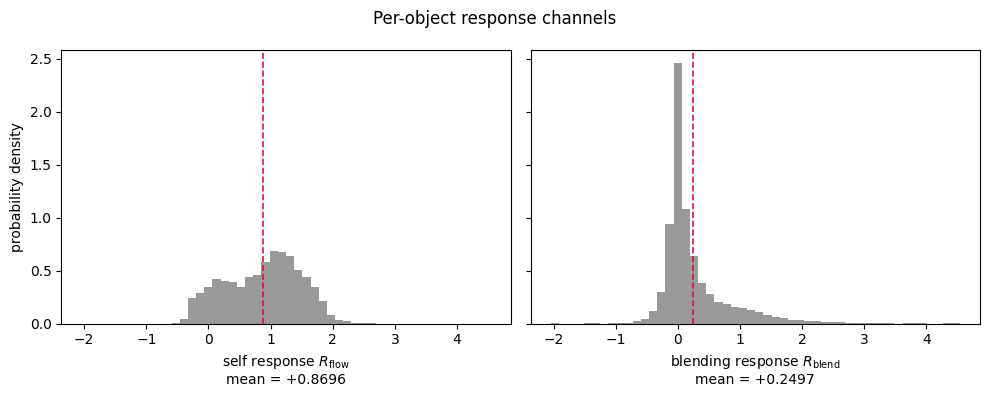

In [6]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
channels = (
    (prediction.flow, r"self response $R_{\mathrm{flow}}$"),
    (prediction.blend, r"blending response $R_{\mathrm{blend}}$"),
)
lo = min(values.min() for values, _ in channels)
hi = max(values.max() for values, _ in channels)
bins = np.linspace(lo, hi, 51)
for ax, (values, label) in zip(axes, channels):
    ax.hist(values, bins=bins, density=True, color="0.6")
    ax.axvline(values.mean(), color="crimson", ls="--", lw=1.2)
    ax.set_xlabel(f"{label}\nmean = {values.mean():+.4f}")
axes[0].set_ylabel("probability density")
fig.suptitle("Per-object response channels")
fig.tight_layout()
plt.show()

### Detection probability per galaxy

The detection classifier ships with the same BlendEMU emulator suite we
loaded above, so no new import is needed: `task="detection"` asks it for the
probability that each *paired* galaxy is detected, from the same pair
features the blend response uses.  A primary with several neighbours gets
one probability per pair; here we keep the most threatening one (`min`),
which is the natural worst-case reduction.  Isolated galaxies carry no pair
at all, so a convention is needed for them in general -- in this catalogue
every retained primary has at least one pair, and the pair table is the same
one `r_blend` was built from, so the alignment is exact.
You will see an extrapolation warning on this catalogue: the classifier
was trained on pairs within about 3 arcsec, and most example-catalogue
pairs are further out than that.  Their probabilities are extrapolations
-- the warning is printed for exactly this reason.

In [7]:
detection = emulator.predict_on_pairs(prepared.emulator_pairs, task="detection", rescaled=True)
p_detect = detection.groupby("primary_row")["detection_prob"].min()
p_detect.describe()

/scratch-local/slurm-job-tmp-15806251/ipykernel_2962306/206978715.py:1: UserWarning: [blendemu:detection] 109874 input rows, extrapolation outside training boundaries:
  sersic_n_input_p: 1762/109874 outside [0.513, 5.85] (input range [0.5, 6])
  sersic_n_input_s: 719/109874 outside [0.513, 5.85] (input range [0.5, 6])
  distance_scaled: 81885/109874 outside [0.000782, 5.59] (input range [5.59, 13.8])
  Predictions for these rows are extrapolations and may be unreliable.
  detection = emulator.predict_on_pairs(prepared.emulator_pairs, task="detection", rescaled=True)


count    10265.000000
mean         0.822924
std          0.319068
min          0.000045
25%          0.884570
50%          0.981616
75%          0.994468
max          0.998714
Name: detection_prob, dtype: float64

In [8]:
# Total model response per primary, weighted by detection probability.
import pandas as pd

per_primary = pd.DataFrame({
    "R_flow": pd.Series(prediction.flow, index=prediction.index),
    "R_blend": r_blend,
    "P_detect": p_detect,
})
per_primary["R_total"] = per_primary["R_flow"] + per_primary["R_blend"]
per_primary["R_total_detected"] = per_primary["R_total"] * per_primary["P_detect"]
print(
    f"mean R_total            = {per_primary['R_total'].mean():.4f}\n"
    f"mean R_total x P_detect = {per_primary['R_total_detected'].mean():.4f}"
)
per_primary.head()

mean R_total            = 1.1193
mean R_total x P_detect = 0.9414


,R_flow,R_blend,P_detect,R_total,R_total_detected
17,1.738613,0.068758,0.992163,1.807371,1.793206
25,0.861486,0.176663,0.965868,1.038150,1.002715
30,1.305665,-0.205264,0.971711,1.100401,1.069271
46,0.554869,-0.165402,0.978702,0.389468,0.381173
91,1.040207,0.585384,0.990242,1.625591,1.609729


### Reusing emulator output you already have

If you ran the emulator earlier and saved the result. Hand `predict` the saved catalogue and name the column holding the response; it joins on `(case, input_index)`:

```python
EMULATOR_RESPONSE_CATALOGUE = Path("/path/to/emulator_response.feather")
prediction = predictor.predict(
    prepared.flow_inputs,
    blend_catalogue=EMULATOR_RESPONSE_CATALOGUE,
    blend_response="R_blend",
)
```

And if `R_blend` is already a column of `prepared.flow_inputs`, a plain `predictor.predict(prepared.flow_inputs)` picks it up.

One warning, because it is the easiest way to get a quietly wrong answer: alignment has to come from stable object keys or from the way you built the table. Two DataFrames of the same length are not necessarily in the same order. Rows SBSI cannot match are dropped — they are never treated as `R_blend = 0`.

### Reading the result

`prediction` carries per-object `prediction.flow`, `prediction.blend`, and `prediction.total`, with `prediction.total_mean` for the catalogue average. `prediction.summary()` prints the short version: how many objects and seeds went in, the three mean responses, and `R_flow_seed_sem` — the scatter across the ensemble seeds, which is your handle on how much the flow itself is uncertain.

### Comparing against a simulation

Once you have a matched simulation response, the multiplicative bias is

$$m = R_{\mathrm{sim}} / R_{\mathrm{model}} - 1.$$

```python
m = prediction.multiplicative_bias(simulation_response)
print(f"m = {100 * m:+.3f}%")
```

## 5. Catalogue-level shear inference — not ready yet

The long-term goal is to skip the response-and-bias detour entirely and infer shear directly, putting the measurement flow and the neighbour emulator inside a single simulation-based likelihood.